# Multivariate Data Visualization

---

## 1. Apa itu Multivariate Data?

Data multivariat adalah data yang memiliki **lebih dari dua variabel/fitur** untuk setiap observasi. Hampir semua data dunia nyata bersifat multivariat — data pasien rumah sakit memiliki ratusan parameter lab, data e-commerce memiliki puluhan atribut produk, dan data sensor IoT bisa merekam ribuan sinyal sekaligus.

Tantangan utamanya sederhana: **manusia hanya dapat melihat dan memahami dunia dalam maksimal 3 dimensi.** Ketika data memiliki 10, 50, atau 500 dimensi, kita membutuhkan teknik khusus untuk dapat "melihat" data tersebut.

---

## 2. Teknik Visualisasi Multivariate

Secara garis besar, ada dua pendekatan untuk memvisualisasikan data multivariat.

### A. Visualisasi Langsung (Tanpa Reduksi Dimensi)

Beberapa teknik memungkinkan kita menampilkan beberapa dimensi sekaligus dalam satu plot, meskipun tetap terbatas:

- **Scatter Plot Matrix (Pairs Plot)** — menampilkan scatter plot untuk setiap pasang fitur sekaligus
- **Heatmap Korelasi** — menampilkan nilai korelasi antar semua fitur dalam bentuk matriks warna
- **Parallel Coordinates Plot** — setiap fitur menjadi sumbu vertikal, setiap observasi menjadi garis yang menghubungkan semua sumbu
- **Radar / Spider Chart** — menampilkan nilai beberapa variabel dalam bentuk jaring laba-laba

Teknik-teknik ini mulai tidak efektif saat fitur berjumlah lebih dari ~15–20.

### B. Visualisasi dengan Reduksi Dimensi

Pendekatan ini memproyeksikan data ke 2D atau 3D terlebih dahulu, lalu memvisualisasikannya sebagai scatter plot biasa. Metode yang umum digunakan adalah **PCA**, **t-SNE**, dan **UMAP**.

---

## 3. t-SNE (t-Distributed Stochastic Neighbor Embedding)

### Definisi

t-SNE adalah algoritma reduksi dimensi **non-linear** yang dirancang khusus untuk keperluan **visualisasi**. Berbeda dengan PCA yang berusaha mempertahankan varians global, t-SNE berusaha mempertahankan **kemiripan lokal** antar titik data — titik yang mirip di dimensi tinggi akan ditempatkan berdekatan di dimensi rendah.

Dikembangkan oleh **Laurens van der Maaten dan Geoffrey Hinton (2008)**, t-SNE menjadi standar de facto untuk eksplorasi visual data berdimensi tinggi.

### Ide Inti

Bayangkan kamu punya 1000 orang di sebuah kota besar (dimensi tinggi). Kamu ingin memindahkan mereka ke sebuah lapangan kecil (2D) dengan aturan: **orang yang saling kenal harus tetap berdekatan**. t-SNE melakukan hal persis seperti itu — ia mempertahankan "kedekatan" antar data, bukan nilai absolutnya.

### Cara Kerja

**Langkah 1 — Hitung kemiripan di dimensi tinggi**

Untuk setiap pasang titik $x_i$ dan $x_j$, hitung probabilitas bahwa keduanya adalah "tetangga" menggunakan distribusi Gaussian:

$$p_{j|i} = \frac{\exp\left(-\|x_i - x_j\|^2 / 2\sigma_i^2\right)}{\sum_{k \neq i} \exp\left(-\|x_i - x_k\|^2 / 2\sigma_i^2\right)}$$

Probabilitas disimetriskan menjadi:

$$p_{ij} = \frac{p_{j|i} + p_{i|j}}{2n}$$

**Langkah 2 — Inisialisasi posisi di dimensi rendah**

Titik-titik data ditempatkan secara acak di ruang 2D.

**Langkah 3 — Hitung kemiripan di dimensi rendah**

Di ruang 2D, kemiripan dihitung menggunakan **distribusi t-Student** (bukan Gaussian). Ekor distribusi t-Student yang lebih tebal membantu mencegah titik-titik "berdesakan" di tengah:

$$q_{ij} = \frac{\left(1 + \|y_i - y_j\|^2\right)^{-1}}{\sum_{k \neq l}\left(1 + \|y_k - y_l\|^2\right)^{-1}}$$

**Langkah 4 — Optimasi dengan Gradient Descent**

t-SNE meminimalkan perbedaan antara distribusi $P$ (dimensi tinggi) dan $Q$ (dimensi rendah) menggunakan **KL-Divergence**:

$$C = KL(P \| Q) = \sum_{i,j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$

Proses ini diulang secara iteratif hingga konvergen.

---

## 4. Parameter Kunci t-SNE

| Parameter | Default | Pengaruh |
|:----------|:-------:|:---------|
| `perplexity` | 30 | Jumlah tetangga efektif. Rentang umum: 5–50. Rendah = fokus lokal, Tinggi = lebih global |
| `learning_rate` | 200 | Kecepatan update posisi saat gradient descent |
| `n_iter` | 1000 | Jumlah iterasi optimasi |
| `n_components` | 2 | Dimensi output (hampir selalu 2 atau 3) |

> ⚠️ **Catatan penting:** Hasil t-SNE **tidak deterministik** — setiap run bisa menghasilkan visualisasi berbeda. Selalu gunakan `random_state` untuk reproducibility. Selain itu, **jarak absolut antar kluster di plot t-SNE tidak bermakna** — yang penting adalah apakah titik-titik berada dalam kluster yang sama atau tidak.

---

## 5. t-SNE vs PCA

| Aspek | PCA | t-SNE |
|:------|:----|:------|
| **Jenis transformasi** | Linear | Non-linear |
| **Fokus** | Varians global | Kemiripan lokal |
| **Kecepatan** | Sangat cepat | Lambat (O(n²)) |
| **Cocok untuk** | Preprocessing, reduksi umum | Visualisasi & eksplorasi |
| **Sensitif terhadap outlier** | Ya | Lebih tahan |
| **Hasil reproducible** | Ya | Tidak (perlu `random_state`) |
| **Bisa transform data baru** | Ya | Tidak (perlu fit ulang) |

---

## 6. Implementasi Python

Kita akan menggunakan **Wine Dataset** dari sklearn — dataset yang berisi hasil analisis kimia dari **178 sampel wine** yang berasal dari **3 varietas anggur berbeda** di Italia. Setiap sampel memiliki **13 fitur numerik** seperti kadar alkohol, malic acid, flavanoids, dan sebagainya.

### **Setup**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

### **Load & Eksplorasi Data**

In [ ]:
# Load dataset
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
class_names = wine.target_names  # ['class_0', 'class_1', 'class_2']

df = pd.DataFrame(X, columns=feature_names)
df['variety'] = [class_names[i] for i in y]

print("=== Info Dataset ===")
print(f"Jumlah sampel : {X.shape[0]}")
print(f"Jumlah fitur  : {X.shape[1]}")
print(f"Jumlah kelas  : {len(class_names)}")
print(f"\nNama fitur:\n{feature_names}")
print(f"\nDistribusi kelas:\n{df['variety'].value_counts()}")

=== Info Dataset ===
Jumlah sampel : 178
Jumlah fitur  : 13
Jumlah kelas  : 3

Nama fitur:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Distribusi kelas:
variety
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64


In [4]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,variety
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,class_0


In [3]:
print("\n=== Statistik Deskriptif ===")
print(df.drop('variety', axis=1).describe().round(2))


=== Statistik Deskriptif ===
       alcohol  malic_acid     ash  alcalinity_of_ash  magnesium  \
count   178.00      178.00  178.00             178.00     178.00   
mean     13.00        2.34    2.37              19.49      99.74   
std       0.81        1.12    0.27               3.34      14.28   
min      11.03        0.74    1.36              10.60      70.00   
25%      12.36        1.60    2.21              17.20      88.00   
50%      13.05        1.87    2.36              19.50      98.00   
75%      13.68        3.08    2.56              21.50     107.00   
max      14.83        5.80    3.23              30.00     162.00   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count         178.00      178.00                178.00           178.00   
mean            2.30        2.03                  0.36             1.59   
std             0.63        1.00                  0.12             0.57   
min             0.98        0.34                  0.13   

### **Heatmap Visualization**

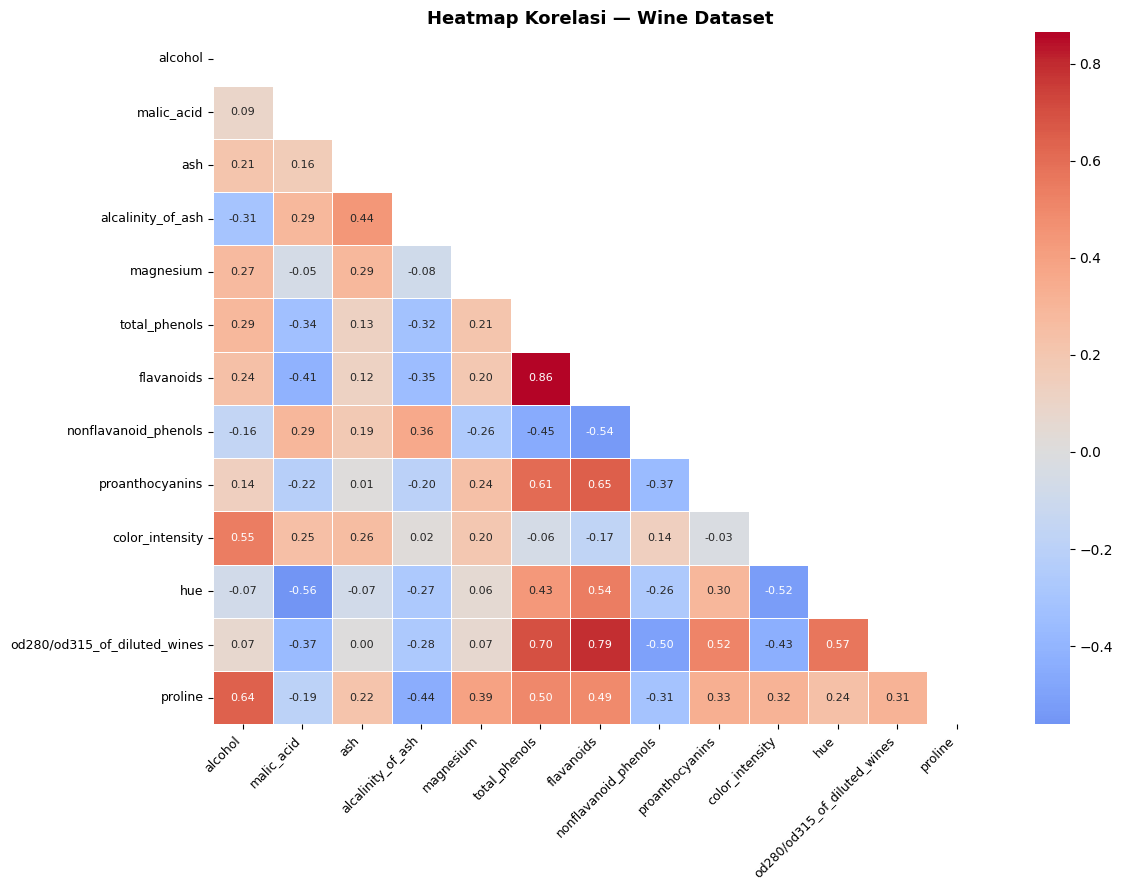

In [5]:
plt.figure(figsize=(12, 9))
corr_matrix = df.drop('variety', axis=1).corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            linewidths=0.5,
            annot_kws={'size': 8})

plt.title('Heatmap Korelasi — Wine Dataset', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

> Dari heatmap ini kita bisa melihat fitur mana yang berkorelasi kuat. Misalnya, flavanoids dan total_phenols memiliki korelasi tinggi (~0.86), yang berarti keduanya membawa informasi yang redundan.

### **Pair Plot**

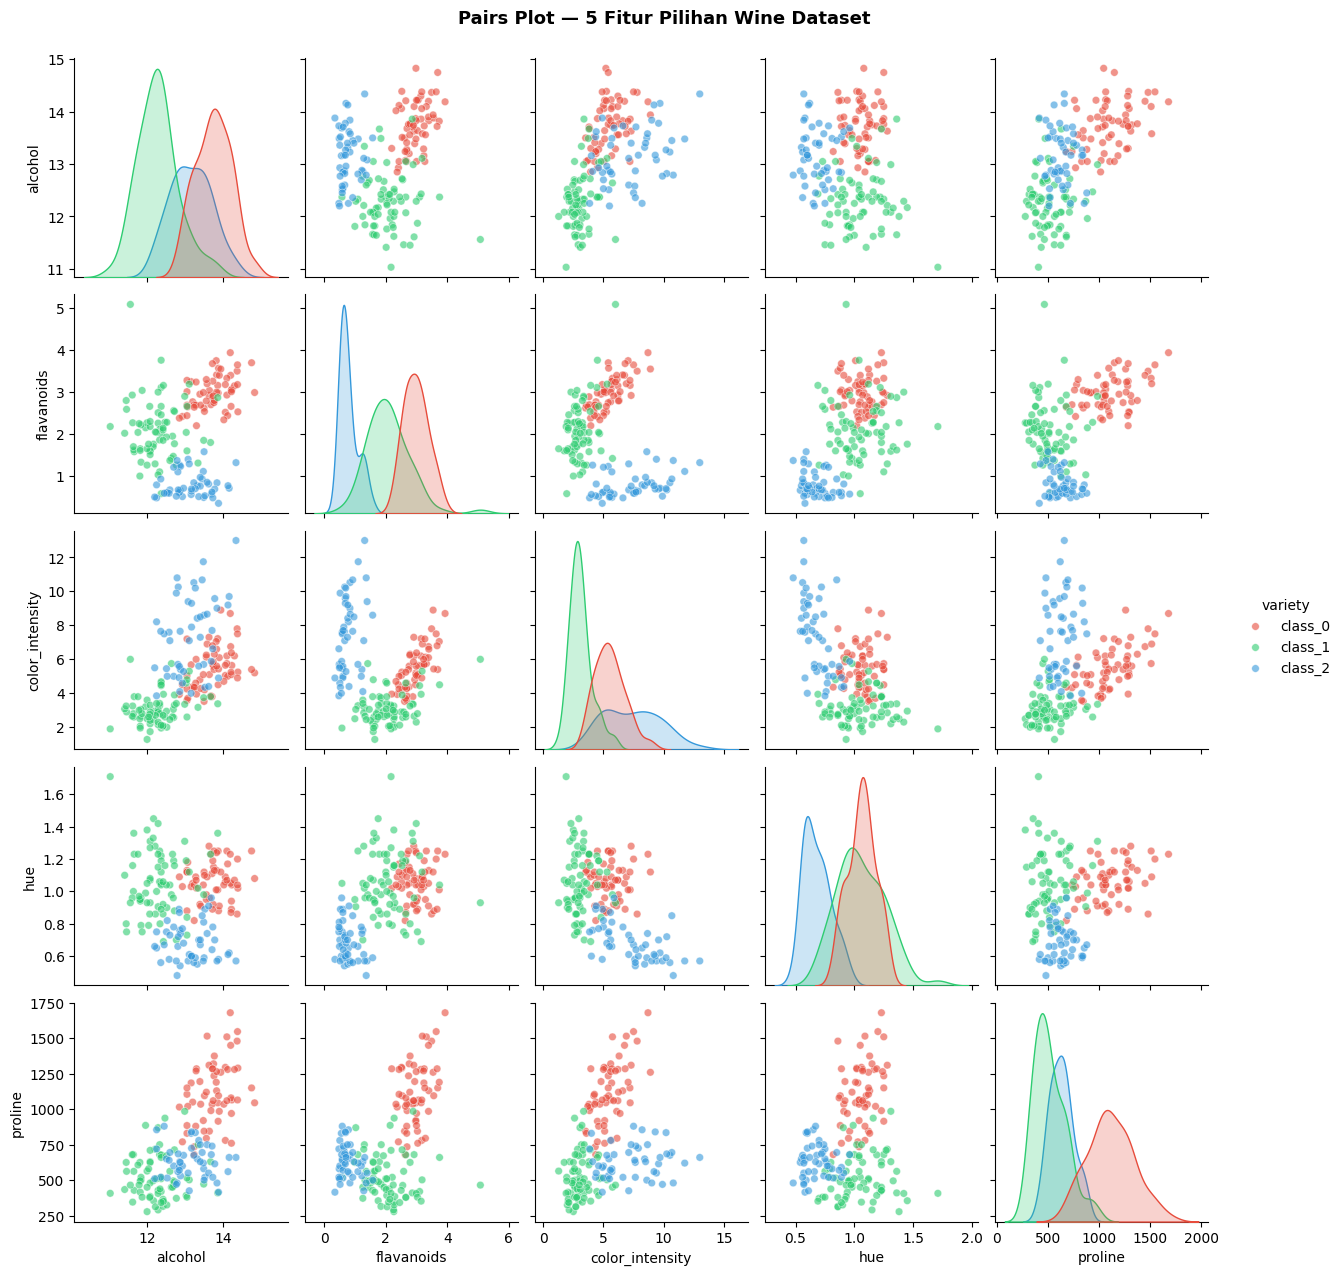

In [6]:
# Pilih 5 fitur paling informatif untuk pairs plot
selected_features = ['alcohol', 'flavanoids', 'color_intensity', 'hue', 'proline']
df_selected = df[selected_features + ['variety']]

palette = {'class_0': '#e74c3c', 'class_1': '#2ecc71', 'class_2': '#3498db'}

g = sns.pairplot(df_selected,
                 hue='variety',
                 palette=palette,
                 plot_kws={'alpha': 0.6, 's': 30},
                 diag_kind='kde')

g.fig.suptitle('Pairs Plot — 5 Fitur Pilihan Wine Dataset',
               y=1.02, fontsize=13, fontweight='bold')
plt.show()

### **Standarisasi Data**

In [7]:
# Wajib dilakukan sebelum PCA dan t-SNE
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Mean setelah scaling : {X_scaled.mean():.6f}")  # ≈ 0
print(f"Std setelah scaling  : {X_scaled.std():.6f}")   # ≈ 1

Mean setelah scaling : 0.000000
Std setelah scaling  : 1.000000


### **PCA**

In [8]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

ev = pca.explained_variance_ratio_
print(f"Explained Variance PC1 : {ev[0]*100:.2f}%")
print(f"Explained Variance PC2 : {ev[1]*100:.2f}%")
print(f"Total                  : {sum(ev)*100:.2f}%")

Explained Variance PC1 : 36.20%
Explained Variance PC2 : 19.21%
Total                  : 55.41%


### **Plot PCA**

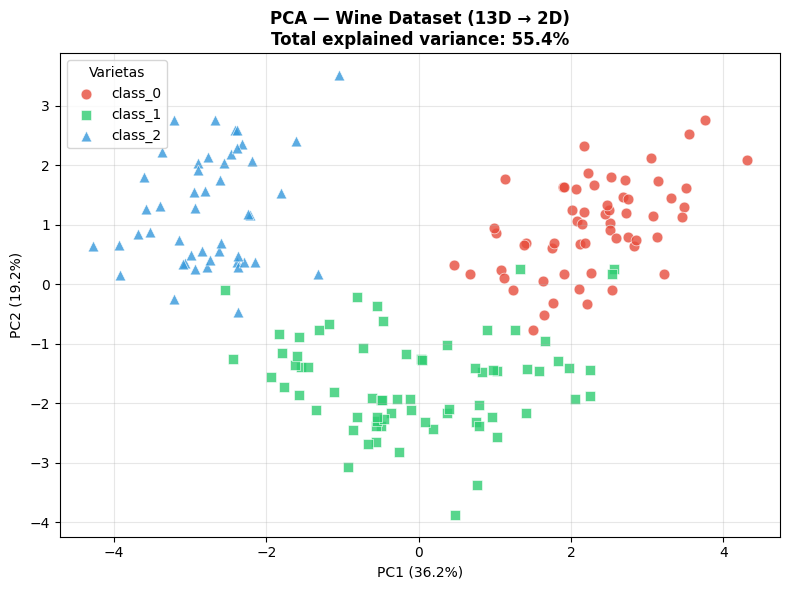

In [9]:
# Plot PCA
colors = {'class_0': '#e74c3c', 'class_1': '#2ecc71', 'class_2': '#3498db'}
markers = {'class_0': 'o', 'class_1': 's', 'class_2': '^'}

plt.figure(figsize=(8, 6))
for label, name in enumerate(class_names):
    mask = y == label
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[name], marker=markers[name],
                label=name, alpha=0.8, s=60, edgecolors='white', linewidth=0.5)

plt.title(f'PCA — Wine Dataset (13D → 2D)\nTotal explained variance: {sum(ev)*100:.1f}%',
          fontsize=12, fontweight='bold')
plt.xlabel(f'PC1 ({ev[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({ev[1]*100:.1f}%)')
plt.legend(title='Varietas', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### **t-SNE**

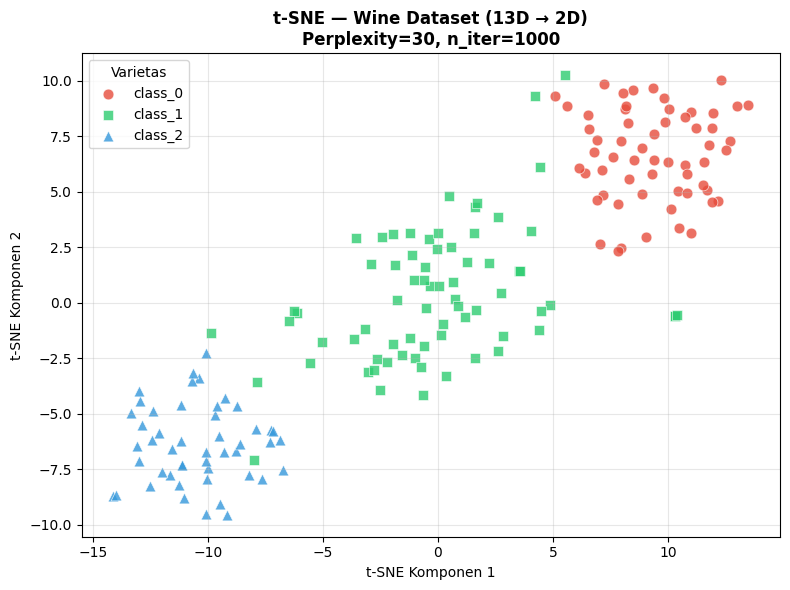

In [11]:
tsne = TSNE(n_components=2,
            perplexity=30,
            learning_rate=200,
            max_iter=1000,
            random_state=42)

X_tsne = tsne.fit_transform(X_scaled)

# Plot t-SNE
plt.figure(figsize=(8, 6))
for label, name in enumerate(class_names):
    mask = y == label
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                c=colors[name], marker=markers[name],
                label=name, alpha=0.8, s=60, edgecolors='white', linewidth=0.5)

plt.title('t-SNE — Wine Dataset (13D → 2D)\nPerplexity=30, n_iter=1000',
          fontsize=12, fontweight='bold')
plt.xlabel('t-SNE Komponen 1')
plt.ylabel('t-SNE Komponen 2')
plt.legend(title='Varietas', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### **PCA vs t-SNE**

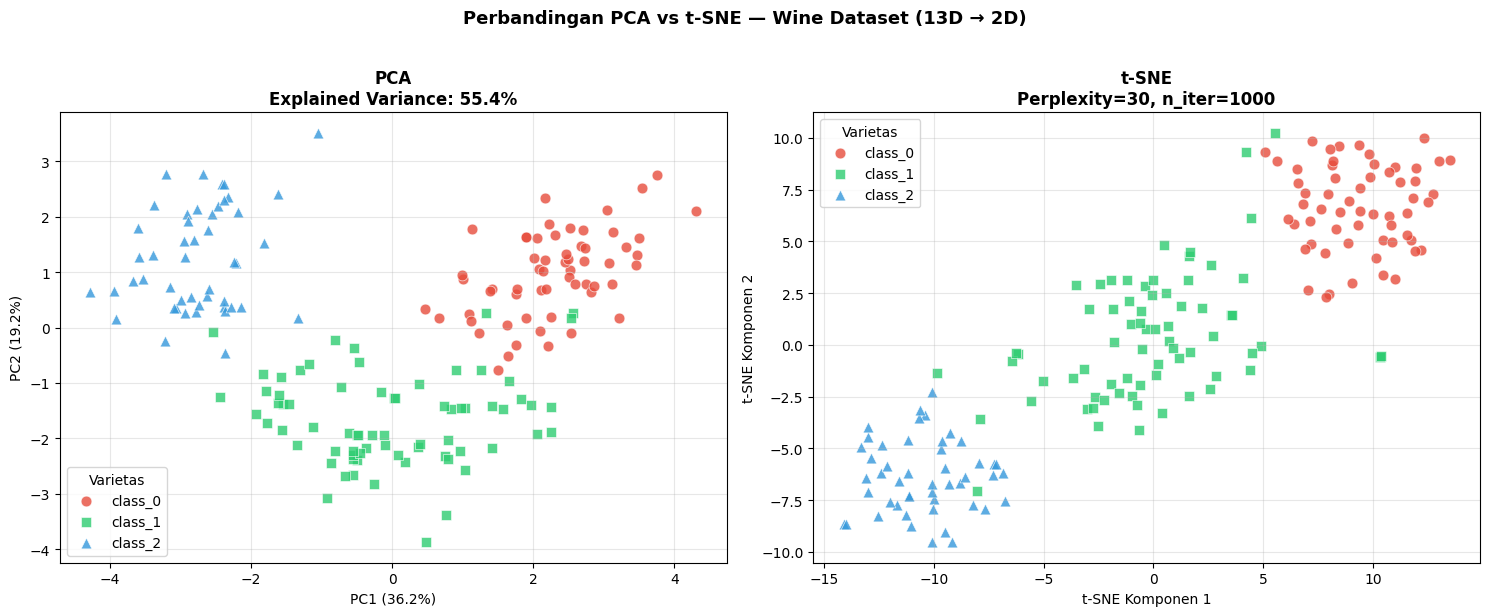

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel kiri: PCA
for label, name in enumerate(class_names):
    mask = y == label
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colors[name], marker=markers[name],
                    label=name, alpha=0.8, s=60,
                    edgecolors='white', linewidth=0.5)
axes[0].set_title(f'PCA\nExplained Variance: {sum(ev)*100:.1f}%', fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({ev[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({ev[1]*100:.1f}%)')
axes[0].legend(title='Varietas')
axes[0].grid(True, alpha=0.3)

# Panel kanan: t-SNE
for label, name in enumerate(class_names):
    mask = y == label
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    c=colors[name], marker=markers[name],
                    label=name, alpha=0.8, s=60,
                    edgecolors='white', linewidth=0.5)
axes[1].set_title('t-SNE\nPerplexity=30, n_iter=1000', fontsize=12, fontweight='bold')
axes[1].set_xlabel('t-SNE Komponen 1')
axes[1].set_ylabel('t-SNE Komponen 2')
axes[1].legend(title='Varietas')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Perbandingan PCA vs t-SNE — Wine Dataset (13D → 2D)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### **Pengaruh Perplexity pada t-SNE**

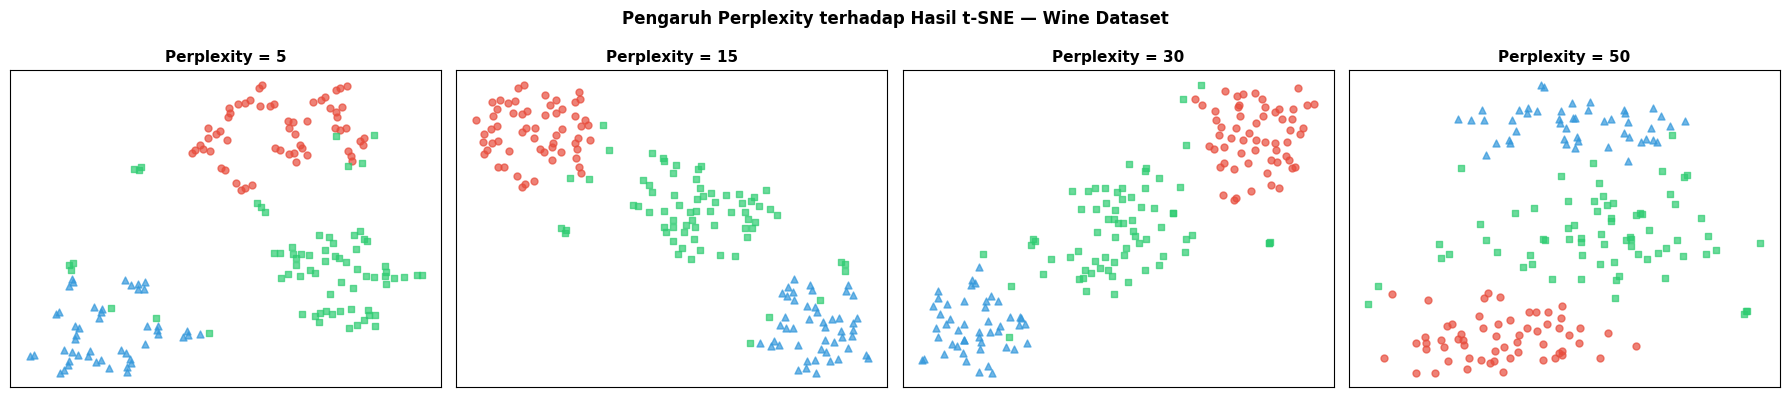

In [14]:
perplexities = [5, 15, 30, 50]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, perp in zip(axes, perplexities):
    tsne_exp = TSNE(n_components=2, perplexity=perp,
                    learning_rate=200, max_iter=1000, random_state=42)
    X_temp = tsne_exp.fit_transform(X_scaled)

    for label, name in enumerate(class_names):
        mask = y == label
        ax.scatter(X_temp[mask, 0], X_temp[mask, 1],
                   c=colors[name], marker=markers[name],
                   alpha=0.7, s=25)

    ax.set_title(f'Perplexity = {perp}', fontsize=11, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('Pengaruh Perplexity terhadap Hasil t-SNE — Wine Dataset',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Interpretasi Hasil

**Dari heatmap korelasi**, kita menemukan beberapa pasang fitur yang sangat berkorelasi (seperti `flavanoids`–`total_phenols`). Ini mengindikasikan bahwa data memiliki redundansi dan reduksi dimensi sangat relevan untuk dilakukan.

**Dari pairs plot**, sudah terlihat bahwa beberapa fitur seperti `flavanoids` dan `proline` cukup baik dalam memisahkan ketiga kelas, namun tidak ada satu pun pasang fitur yang memisahkan ketiga kelas secara sempurna.

**PCA** berhasil memisahkan ketiga varietas wine dengan cukup baik (~55% informasi tertangkap dalam 2 PC). Namun beberapa titik masih overlap, terutama antara class_1 dan class_2.

**t-SNE** menghasilkan kluster yang jauh lebih bersih dan terpisah. Ketiga varietas membentuk "pulau" tersendiri yang hampir tidak overlap sama sekali. Ini menunjukkan bahwa hubungan antar varietas di dataset ini bersifat non-linear dan t-SNE mampu mengungkap struktur tersebut.

---

## 8. Tips Praktis

**Selalu standardisasi data terlebih dahulu.** t-SNE dan PCA sensitif terhadap skala fitur. Fitur dengan rentang nilai besar (seperti `proline` yang bisa mencapai 1680) akan mendominasi jika tidak distandarisasi.

**Eksperimen dengan perplexity.** Tidak ada nilai perplexity yang universal terbaik. Sebagai panduan: gunakan nilai yang lebih kecil untuk dataset kecil, dan nilai lebih besar untuk dataset yang lebih besar.

**Jalankan beberapa kali.** Karena t-SNE tidak deterministik, gunakan beberapa nilai `random_state` untuk memastikan pola yang terlihat memang konsisten.

**Jangan gunakan koordinat t-SNE sebagai fitur model.** Hasil t-SNE hanya untuk **visualisasi**. Koordinat yang dihasilkan tidak dapat digeneralisasi ke data baru karena t-SNE tidak memiliki fungsi transform yang dapat diaplikasikan ke sampel baru.

---

## 9. Kapan Menggunakan Teknik Apa?

```
Tujuan: Memahami korelasi antar fitur
→ Heatmap korelasi

Tujuan: Eksplorasi distribusi dan hubungan antar fitur
→ Pairs plot / scatter matrix

Tujuan: Reduksi fitur sebelum training model
→ PCA

Tujuan: Visualisasi kluster & eksplorasi pola tersembunyi
→ t-SNE

Tujuan: Dataset sangat besar (>100K sampel)
→ UMAP (lebih cepat dari t-SNE, kualitas sebanding)
```

---

*Referensi: van der Maaten, L. & Hinton, G. (2008). Visualizing Data using t-SNE. Journal of Machine Learning Research. | Wattenberg, M., Viégas, F., Johnson, I. (2016). How to Use t-SNE Effectively. Distill.*